# **Détection des dattes fruits avec YOLOv8**

In [35]:
import os
import shutil
import zipfile
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import random





* ***Préparer Data pour entrainement avec Yolov8*** : (labels + images)

In [36]:
BASE_DIR = "../data/dataset_detection/"

# IMAGES_DIR = f"{BASE_DIR}/data_merged/images"
# LABELS_DIR = f"{BASE_DIR}/data_merged/labels"




IMAGES_DIR = os.path.join(BASE_DIR, "data_merged/images")
LABELS_DIR = os.path.join(BASE_DIR, "data_merged/labels")


IMAGE_EXT = [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]

In [37]:
print("Images :", len(os.listdir(IMAGES_DIR)))
print("Labels :", len(os.listdir(LABELS_DIR)))

Images : 9091
Labels : 9029


*  vérifie chaque image

*  affiche celles qui n'ont pas de label

*  les supprime





In [38]:


def remove_images_without_labels(images_dir, labels_dir, image_ext, show_images=True):
    """
    Vérifie les images sans label YOLO et les supprime.

    Args:
        images_dir : dossier des images
        labels_dir : dossier des annotations
        image_ext : extensions autorisées
        show_images : afficher les images supprimées
    """

    missing_images = []

    # vérifier les labels
    for img in os.listdir(images_dir):

        if os.path.splitext(img)[1].lower() in image_ext:

            name = os.path.splitext(img)[0]
            label_path = os.path.join(labels_dir, name + ".txt")

            if not os.path.exists(label_path):
                missing_images.append(img)

    print("Images sans label :", len(missing_images))

    # afficher les images
    if show_images:
        for img in missing_images:

            img_path = os.path.join(images_dir, img)

            image = cv2.imread(img_path)

            if image is None:
                continue

            # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # plt.figure(figsize=(4,4))
            # plt.imshow(image)
            # plt.title(f"Sans label : {img}")
            # plt.axis("off")
            # plt.show()

    # supprimer les images
    for img in missing_images:
        os.remove(os.path.join(images_dir, img))

    print(f"🗑️ {len(missing_images)} images supprimées")

    return missing_images

In [39]:
remove_images_without_labels(
    IMAGES_DIR,
    LABELS_DIR,
    IMAGE_EXT
)


Images sans label : 81
🗑️ 81 images supprimées


['20220901_175903.jpg',
 '20220901_180251(0).jpg',
 '20220901_180251.jpg',
 '20220901_180301.jpg',
 '20220901_182604.jpg',
 '20220919_185836(0).jpg',
 '20220919_185916.jpg',
 '20220919_190051.jpg',
 '20220919_190052.jpg',
 '20220919_190053.jpg',
 '20220919_190124.jpg',
 '20220919_190125.jpg',
 '20220919_190403(0).jpg',
 '20220919_190403.jpg',
 '20220919_190404(0).jpg',
 '20220919_190404.jpg',
 '20220919_190405.jpg',
 '20220919_190406(0).jpg',
 '20220919_190406.jpg',
 '20220919_190407.jpg',
 '20220919_190538(0).jpg',
 '20220919_190539(0).jpg',
 '20220919_190540.jpg',
 '20220919_190541.jpg',
 '20220919_190542(0).jpg',
 '20220919_190542.jpg',
 '20220919_190617.jpg',
 '20220919_190618.jpg',
 '20220919_190659.jpg',
 '20220919_190700.jpg',
 '20220919_190701(0).jpg',
 '20220919_190701.jpg',
 '20220919_190702.jpg',
 '20220920_124734.jpg',
 '20220920_125630.jpg',
 '20220922_132227.jpg',
 '20220922_132401.jpg',
 '20220922_132457.jpg',
 '20220922_132504(0).jpg',
 '20220922_132506.jpg',
 '20220922

In [40]:
print("Images :", len(os.listdir(IMAGES_DIR)))
print("Labels :", len(os.listdir(LABELS_DIR)))

Images : 9010
Labels : 9029


***

* Afficher une échantillon des images :

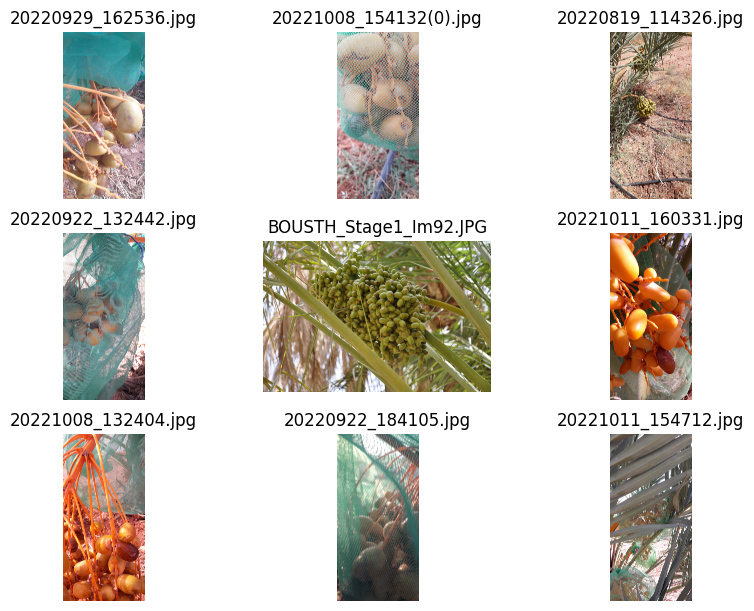

In [41]:



# -----------------------------
# lire les annotations YOLO
# -----------------------------
def read_yolo_label(label_path):

    boxes = []

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        cls, xc, yc, w, h = map(float, line.split())
        boxes.append((cls, xc, yc, w, h))

    return boxes


# -----------------------------
# dessiner bounding boxes
# -----------------------------
def draw_boxes(image, boxes):

    h, w, _ = image.shape

    for cls, xc, yc, bw, bh in boxes:

        x_center = xc * w
        y_center = yc * h

        box_w = bw * w
        box_h = bh * h

        x_min = int(x_center - box_w / 2)
        y_min = int(y_center - box_h / 2)

        x_max = int(x_center + box_w / 2)
        y_max = int(y_center + box_h / 2)

        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0,0,255), 6)

    return image


# -----------------------------
# afficher échantillons
# -----------------------------
def show_random_samples(n_samples=9):
    images = os.listdir(IMAGES_DIR)

    if len(images) == 0:
        print("❌ Aucun fichier dans le dossier")
        return

    if n_samples > len(images):
        print(f"⚠️ Seulement {len(images)} images disponibles")
        n_samples = len(images)

    samples = random.sample(images, n_samples)

    cols = 3
    rows = (n_samples // cols) + 1

    plt.figure(figsize=(10, 10))

    for i, img_name in enumerate(samples):
        path = os.path.join(IMAGES_DIR, img_name)
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis("off")

    plt.show()


# -----------------------------
# exécuter
# -----------------------------
show_random_samples(9)

## Split Data to Train, Test, Val (70%, 20%, 10%)

1️⃣ mélanger les images
2️⃣ faire le split 70 / 20 / 10
3️⃣ déplacer image + label correspondant ensemble
4️⃣ créer la structure correcte.

In [42]:


def split_detection_dataset(images_dir, labels_dir, base_dir, image_ext,
                            train_ratio=0.7, val_ratio=0.2, test_ratio=0.1):
    """
    Split un dataset de détection en train / val / test (format YOLO)
    """

    # assert train_ratio + val_ratio + test_ratio == 1.0, "Les ratios doivent faire 1"

    # créer dossiers
    splits = ["data_splited/train", "data_splited/val", "data_splited/test"]

    for split in splits:
        os.makedirs(os.path.join(base_dir, split, "images"), exist_ok=True)
        os.makedirs(os.path.join(base_dir, split, "labels"), exist_ok=True)

    # récupérer images
    images = [f for f in os.listdir(images_dir) if f.lower().endswith(tuple(image_ext))]

    random.shuffle(images)

    n_total = len(images)
    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    train_images = images[:n_train]
    val_images = images[n_train:n_train+n_val]
    test_images = images[n_train+n_val:]


    def move_files(image_list, split):

        for img in image_list:

            name = os.path.splitext(img)[0]

            img_src = os.path.join(images_dir, img)
            lbl_src = os.path.join(labels_dir, name + ".txt")

            img_dst = os.path.join(base_dir, split, "images", img)
            lbl_dst = os.path.join(base_dir, split, "labels", name + ".txt")

            shutil.move(img_src, img_dst)

            if os.path.exists(lbl_src):
                shutil.move(lbl_src, lbl_dst)


    # déplacer fichiers
    move_files(train_images, "data_splited/train")
    move_files(val_images, "data_splited/val")
    move_files(test_images, "data_splited/test")

    print("\n✅ Dataset split terminé")
    print("Train :", len(train_images))
    print("Val :", len(val_images))
    print("Test :", len(test_images))

In [43]:
# IMAGES_DIR = os.path.join(BASE_DIR, "data_splited/images")
# LABELS_DIR = os.path.join(BASE_DIR, "data_splited/labels")

train_ratio=0.7
val_ratio=0.2
test_ratio = 1 - train_ratio - val_ratio

split_detection_dataset(
    IMAGES_DIR,
    LABELS_DIR,
    BASE_DIR,
    IMAGE_EXT,
    train_ratio=train_ratio,
    val_ratio=val_ratio, 
    test_ratio=test_ratio
)


✅ Dataset split terminé
Train : 6307
Val : 1802
Test : 901


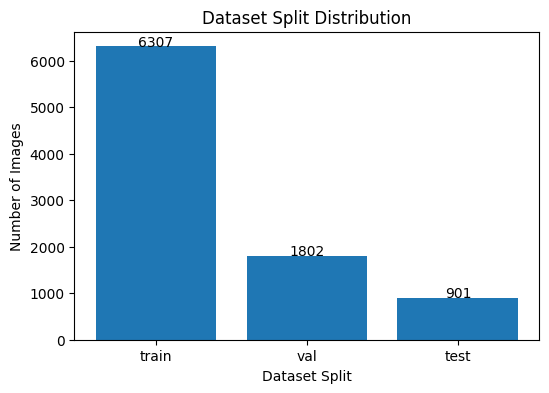

In [44]:
import os
import matplotlib.pyplot as plt

BASE_DIR = "../data/dataset_detection/data_splited/"

def count_images():

    train_count = len(os.listdir(os.path.join(BASE_DIR, "train/images")))
    val_count = len(os.listdir(os.path.join(BASE_DIR, "val/images")))
    test_count = len(os.listdir(os.path.join(BASE_DIR, "test/images")))

    return {
        "train": train_count,
        "val": val_count,
        "test": test_count
    }


def plot_distribution(data):

    labels = list(data.keys())
    values = list(data.values())

    plt.figure(figsize=(6,4))
    plt.bar(labels, values)

    plt.title("Dataset Split Distribution")
    plt.xlabel("Dataset Split")
    plt.ylabel("Number of Images")

    for i,v in enumerate(values):
        plt.text(i, v+5, str(v), ha='center')

    plt.show()


data = count_images()
plot_distribution(data)

In [45]:

list_dirs = {
    "All": "../data/dataset_detection/data_merged",
    "Train": "../data/dataset_detection/data_splited/train",
    "Val": "../data/dataset_detection/data_splited/val",
    "Test": "../data/dataset_detection/data_splited/test",
}


def count_data_splited_part(list_dir):

    for name, path in list_dir.items():

        images_dir = os.path.join(path, "images")
        labels_dir = os.path.join(path, "labels")

        n_images = len(os.listdir(images_dir)) if os.path.exists(images_dir) else 0
        n_labels = len(os.listdir(labels_dir)) if os.path.exists(labels_dir) else 0

        print(f"📂 {name}")
        print(f"Images : {n_images}")
        print(f"Labels : {n_labels}")
        print("=" * 40)


count_data_splited_part(list_dirs)

📂 All
Images : 0
Labels : 19
📂 Train
Images : 6307
Labels : 6307
📂 Val
Images : 1802
Labels : 1802
📂 Test
Images : 901
Labels : 901


In [46]:
!pip install ultralytics


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
# data.yml



# train: ../data/dataset_detection/data_splited/train/images
# val: ../data/dataset_detection/data_splited/val/images
# test: ../data/dataset_detection/data_splited/test/images

# names:
#   0: date

In [48]:
import os

# ✅ IMPORTANT : avant import YOLO
os.environ["MLFLOW_DISABLED"] = "true"
os.environ["MLFLOW_TRACKING_URI"] = ""

from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="../data/dataset_detection/data.yaml",
    imgsz=640,
    epochs=10,
    batch=16,
    project="../analyse_configuration/detection/runs",
    name="train",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.23 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.220  Python-3.13.10 torch-2.7.1+cu118 CUDA:0 (NVIDIA RTX 2000 Ada Generation Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/dataset_detection/data.yaml, degrees=0.0, deterministic=True, device=-1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=tra

2026/03/18 00:24:39 INFO mlflow.tracking.fluent: Experiment with name '../analyse_configuration/detection/runs' does not exist. Creating a new experiment.
2026/03/18 00:24:39 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/03/18 00:24:39 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


MLflow: logging run_id(a6467f5d234a418e83bbedeb02cfb132) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\ramas\OneDrive\Desktop\DateVision_AI\analyse_configuration\detection\runs\train
Starting training for 10 epochs...
Closing dataloader mosaic

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/10      2.05G      1.505       1.98      1.553          1        640: 100% ━━━━━━━━━━━━ 394/394 3.1it/s 2:05<0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 3.5it/s 16.4s0.2ss
                   all       1798       3037      0.621      0.559       0.61      0.299

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/10      2.38G      1.478      1.258      1.505 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001DF822ECAE0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [49]:
from ultralytics import YOLO

def evaluate_model_detection(model_path, data_yaml, split="test", imgsz=640, batch=8, device="cpu"):
    """
    Évaluer un modèle YOLOv8 sur un dataset.

    Args:
        model_path : chemin vers best.pt
        data_yaml : chemin vers data.yaml
        split : train / val / test
        imgsz : taille des images
        batch : batch size
        device : cpu ou cuda

    Returns:
        dict contenant les métriques
    """

    model = YOLO(model_path)

    metrics = model.val(
        data=data_yaml,
        split=split,
        imgsz=imgsz,
        batch=batch,
        device=device,
        verbose=False
    )

    results = {
        "mAP50-95": metrics.box.map,
        "mAP50": metrics.box.map50,
        "precision": metrics.box.p,
        "recall": metrics.box.r
    }

    print("\n📊 Résultats de l'évaluation")
    print("-" * 40)
    print(f"mAP50-95 : {results['mAP50-95']:.4f}")
    print(f"mAP50    : {results['mAP50']:.4f}")
    import numpy as np

    print(f"Precision: {np.mean(results['precision']):.4f}")
    print(f"Recall   : {np.mean(results['recall']):.4f}")

    return results

In [50]:
results = evaluate_model_detection(
    model_path="../analyse_configuration/detection/runs/train/weights/best.pt",
    data_yaml="../data/dataset_detection/data.yaml",
    split="val",
    imgsz=640,
    batch=9,
    device="cpu"
)

Ultralytics 8.3.220  Python-3.13.10 torch-2.7.1+cu118 CPU (Intel Core Ultra 7 165H)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1224.0204.1 MB/s, size: 7638.9 KB)
val: Scanning C:\Users\ramas\OneDrive\Desktop\DateVision_AI\data\dataset_detection\data_splited\val\labels.cache... 1802 images, 0 backgrounds, 4 corrupt: 100% ━━━━━━━━━━━━ 1802/1802 1.2Mit/s 0.0s0s
val: C:\Users\ramas\OneDrive\Desktop\DateVision_AI\data\dataset_detection\data_splited\val\images\20220725_180927.jpg: corrupt JPEG restored and saved
val: C:\Users\ramas\OneDrive\Desktop\DateVision_AI\data\dataset_detection\data_splited\val\images\20220725_180945.jpg: corrupt JPEG restored and saved
val: C:\Users\ramas\OneDrive\Desktop\DateVision_AI\data\dataset_detection\data_splited\val\images\20220725_181007.jpg: corrupt JPEG restored and saved
val: C:\Users\ramas\OneDrive\Desktop\DateVision_AI\data\dataset_detection\data_splited\val\images\202

In [51]:
import cv2
import matplotlib.pyplot as plt
import os

RESULTS_DIR = "../analyse_configuration/detection/runs/detect/val"

images = [
    "confusion_matrix",
    'BoxF1_curve',
    'BoxP_curve',
    'BoxPR_curve',
    'BoxR_curve'
]

def show_evaluation_plots():

    plt.figure(figsize=(16,20))

    for i, img_name in enumerate(images):

        path = os.path.join(RESULTS_DIR, img_name + ".png")

        if os.path.exists(path):

            img = cv2.imread(path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(3,2,i+1)
            plt.imshow(img)
            plt.title(img_name)
            plt.axis("off")

    plt.tight_layout()
    plt.show()


show_evaluation_plots()

<Figure size 1600x2000 with 0 Axes>

In [52]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


def predict_random_image_detection(model, image_dir, conf=0.25):
    """
    Prédire sur une image aléatoire d'un dossier avec YOLOv8.

    Args:
        model : modèle YOLO chargé
        image_dir : dossier contenant les images
        conf : seuil de confiance
    """

    images_list = os.listdir(image_dir)

    if len(images_list) == 0:
        print("❌ Aucun fichier image trouvé")
        return

    random_image = random.choice(images_list)

    image_path = os.path.join(image_dir, random_image)

    print(f"📷 Image choisie : {random_image}")

    predictions = model.predict(
        source=image_path,
        conf=conf
    )

    annotated_img = predictions[0].plot()

    annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,8))
    plt.imshow(annotated_img)
    plt.axis("off")
    plt.show()

📷 Image choisie : 20220901_135454.jpg

image 1/1 c:\Users\ramas\OneDrive\Desktop\DateVision_AI\notebooks\..\data\dataset_detection\data_splited\test\images\20220901_135454.jpg: 640x320 2 dates, 17.3ms
Speed: 3.1ms preprocess, 17.3ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 320)


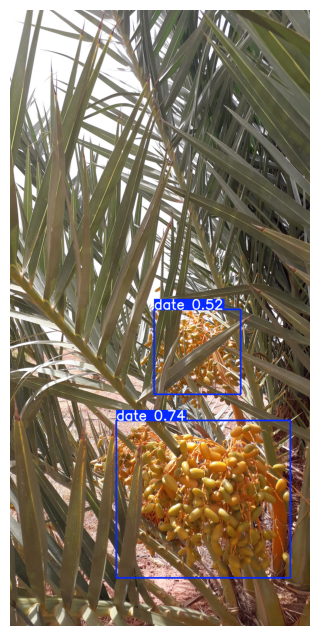

In [53]:
from ultralytics import YOLO

model = YOLO("../analyse_configuration/detection/runs/train/weights/best.pt")

predict_random_image_detection(
    model,
    "../data/dataset_detection/data_splited/test/images"
)

* Sauvegarder le models : 

In [55]:
model.save("../models/date_detector_model.pt")